<div align="center">

# Livrable 1 — Classification Automatique d'Images
## Projet DS Leyenda — TouNum

| | |
|:---|:---|
| **Étudiants**  | *BERRETTA BAPTISTE - HIVER ANDREW - KHALED REFKA - GORDIEN ALEXIS* |
| **Promotion**  | *FISA-INFO A5* |
| **École**      | CESI |
| **Date**       | Mai 2026 |
|:---|:---|
</div>

---

### Contexte métier

L'entreprise **TouNum** se spécialise dans la numérisation de documents pour le compte de ses clients.
Dans le cadre de l'automatisation de son pipeline de traitement, il est nécessaire de **trier
automatiquement les images** selon leur nature avant d'appliquer les algorithmes de captioning.

Ce notebook implémente un **réseau de neurones convolutif (CNN)** capable de classifier des images
en **5 catégories** :

| Classe         | Description                             |
|----------------|-----------------------------------------|
| **Painting**   | Peintures et œuvres d'art               |
| **Photo**      | Photographies réelles                   |
| **Schematics** | Schémas, graphes et diagrammes          |
| **Sketch**     | Portraits dessinés en noir et blanc     |
| **Text**       | Documents textuels scannés              |

### Objectif

Entraîner un modèle de **classification automatique** permettant de distinguer les photos des autres
types d'images, avec une attention particulière à la discrimination entre **photos et peintures**
(le cas le plus difficile visuellement).

### Workflow général

```
Données brutes  ──►  Exploration  ──►  Nettoyage  ──►  Prétraitement
                                                              │
           Interface  ◄──  Évaluation  ◄──  Entraînement  ◄───┘
```


---
## Sommaire

| Section | Titre | Description |
|---------|-------|-------------|
| **0** | [Environnement de Travail](#0) | Installation des dépendances, imports, configuration globale |
| **1** | [Exploration du Dataset](#1) | Distribution des classes, exemples visuels, dimensions |
| **1b** | [Nettoyage des Images](#1b) | Détection et correction des fichiers corrompus |
| **2** | [Préparation des Données](#2) | Chargement, normalisation, augmentation, class weights |
| **3** | [Architecture du Réseau](#3) | Conception et justification du CNN à 4 blocs |
| **4** | [Entraînement](#4) | Callbacks, optimisation, suivi de la convergence |
| **5** | [Analyse des Résultats](#5) | Courbes, métriques, matrice de confusion, erreurs |
| **6** | [Biais / Variance](#6) | Diagnostic de l'apprentissage |
| **7** | [Pistes d'Amélioration](#7) | Transfer learning, régularisation avancée |
| **7b** | [Architecture Externe — fakv8](#7b) | Comparaison avec un CNN tiers |
| **8** | [Interface Interactive](#8) | Test du modèle en conditions réelles |
| **9** | [Conclusion](#9) | Synthèse des résultats et perspectives |

> **Comment utiliser ce notebook :**
> Exécuter les cellules **dans l'ordre** de haut en bas lors de la première exécution.
> Après un restart du kernel, utiliser la cellule de *Reprise rapide* (Section 5) pour recharger le modèle sauvegardé sans ré-entraîner.


---
## 0. Environnement de Travail <a id="0"></a>

Avant toute chose, on s'assure que l'environnement d'exécution est correctement configuré :

- **Dépendances** : les librairies nécessaires sont installées si absentes
- **Imports** : toutes les bibliothèques Python sont chargées
- **Configuration** : les hyperparamètres et chemins sont définis en un seul endroit

> Centraliser la configuration dans une seule cellule (`cell-config`) permet de modifier
> les paramètres (taille d'image, batch size, learning rate) sans toucher au code métier.


In [1]:
# ============================================================
# INSTALLATION DES DÉPENDANCES
# Utilise l'API interne de pip (pas de subprocess) pour installer
# les packages manquants directement dans l'environnement du kernel.
# ============================================================

from pip._internal.cli.main import main as _pip_install

for _pkg in ['seaborn', 'ipywidgets', 'pandas', 'tqdm']:
    try:
        __import__(_pkg)
        print(f"{_pkg} : déjà installé")
    except ImportError:
        print(f"{_pkg} : installation en cours...")
        _pip_install(['install', '--quiet', _pkg])
        print(f"{_pkg} : installé ✓")

print("\nDépendances OK.")

seaborn : déjà installé
ipywidgets : déjà installé
pandas : déjà installé
tqdm : déjà installé

Dépendances OK.


In [2]:
# ============================================================
# IMPORTS
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Reproductibilité : fixer les seeds pour des résultats cohérents entre exécutions
tf.random.set_seed(42)
np.random.seed(42)

# Style des graphiques
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

# Détection et configuration du GPU
print(f"TensorFlow : {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        # memory_growth évite que TF alloue toute la VRAM d'un coup
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU disponible : {gpus[0].name}")
else:
    print("GPU non détecté — entraînement sur CPU (sera plus lent)")

TensorFlow : 2.14.0
GPU disponible : /physical_device:GPU:0


In [ ]:
# ============================================================
# CONFIGURATION GLOBALE
# ============================================================

import os

# --- Résolution du dossier de travail ---
_candidates = ['./data', '/tf/notebooks/data']
DATA_DIR = next((p for p in _candidates if os.path.isdir(p)), None)

if DATA_DIR is None:
    raise FileNotFoundError(
        "Dossier 'data/' introuvable.\n"
        "Vérifiez que le volume Docker est bien monté avec :\n"
        "  -v \"<dossier_projet>:/tf/notebooks\""
    )

os.chdir(os.path.dirname(os.path.abspath(DATA_DIR)))
DATA_DIR = './data'
print(f"Répertoire de travail : {os.getcwd()}")

# Suppression des dossiers internes vides (ex: _corrupt créé par le nettoyage PIL)
# pour qu'image_dataset_from_directory ne les détecte pas comme des classes.
for _d in os.listdir(DATA_DIR):
    _path = os.path.join(DATA_DIR, _d)
    if _d.startswith('_') and os.path.isdir(_path) and not os.listdir(_path):
        os.rmdir(_path)
        print(f"Dossier vide supprimé : {_path}")

# .h5 à la place de .keras — bug TF 2.14 avec ModelCheckpoint natif
MODEL_SAVE_PATH = './model_classification.h5'

IMG_SIZE       = (128, 128)
BATCH_SIZE     = 32
EPOCHS         = 30
LEARNING_RATE  = 1e-4
VAL_SPLIT      = 0.2   # 80% train, 20% pour val+test (chacun 10%)

# sorted() garantit un ordre alphabétique reproductible :
# Painting=0, Photo=1, Schematics=2, Sketch=3, Text=4
CLASS_NAMES = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
    and not d.startswith('_')
])
NUM_CLASSES = len(CLASS_NAMES)

print(f"Classes détectées ({NUM_CLASSES}) : {CLASS_NAMES}")
print(f"Taille des images  : {IMG_SIZE[0]}x{IMG_SIZE[1]} px")
print(f"Batch size         : {BATCH_SIZE}")
print(f"Epochs max         : {EPOCHS}")
print(f"Learning rate      : {LEARNING_RATE}")

Répertoire de travail : /tf/notebooks
Classes détectées (5) : ['Painting', 'Photo', 'Schematics', 'Sketch', 'Text']
Taille des images  : 128x128 px
Batch size         : 32
Epochs max         : 30
Learning rate      : 0.0001


---
## 1. Exploration du Dataset

Avant d'entraîner quoi que ce soit, il est essentiel de **comprendre les données** :
- Combien d'images par classe ?
- Y a-t-il un **déséquilibre de classes** (class imbalance) ?
- À quoi ressemblent les images ?

> Un déséquilibre important peut biaiser le modèle vers les classes majoritaires.
> On le compensera plus tard avec des **class weights**.

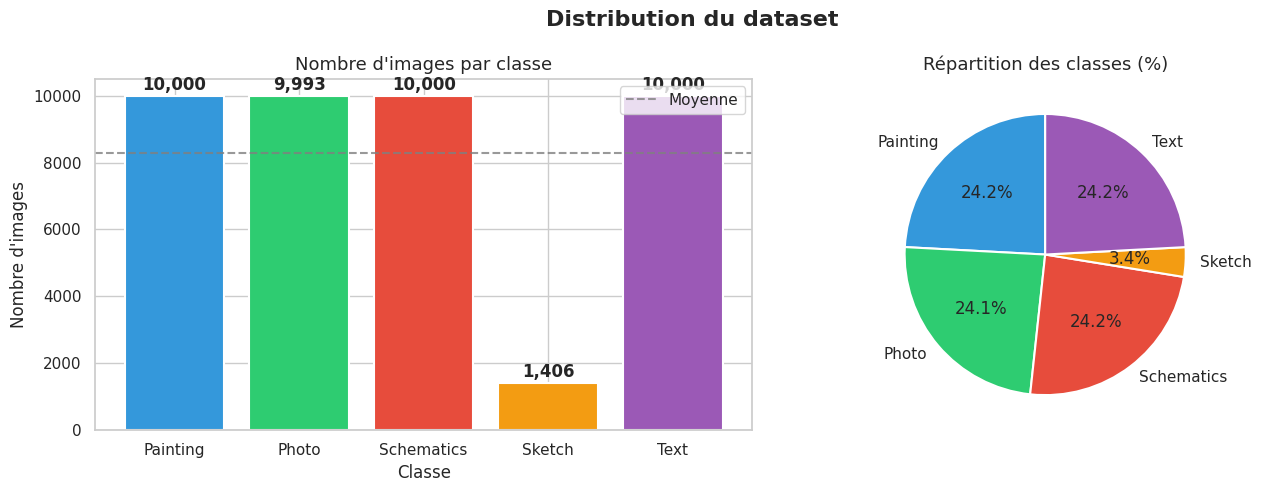


Classe            Images       %
---------------------------------
Painting          10,000   24.2%
Photo              9,993   24.1%
Schematics        10,000   24.2%
Sketch             1,406    3.4% ⚠️
Text              10,000   24.2%
---------------------------------
TOTAL             41,399  100.0%

Ratio max/min : 7.1x — déséquilibre significatif (Sketch sous-représentée). Class weights nécessaires.


In [4]:
# ============================================================
# DISTRIBUTION DES CLASSES
# ============================================================

# Comptage des images pour chaque classe
class_counts = {}
for class_name in CLASS_NAMES:
    class_path = os.path.join(DATA_DIR, class_name)
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
    ]
    class_counts[class_name] = len(images)

total = sum(class_counts.values())

# Visualisation en deux graphiques complémentaires
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution du dataset', fontsize=16, fontweight='bold')

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

# -- Histogramme : permet de voir les valeurs absolues et l'écart entre classes --
bars = ax1.bar(class_counts.keys(), class_counts.values(), color=colors,
               edgecolor='white', linewidth=1.5)
ax1.axhline(total / NUM_CLASSES, color='gray', linestyle='--', alpha=0.8, label='Moyenne')
ax1.set_title("Nombre d'images par classe", fontsize=13)
ax1.set_xlabel('Classe')
ax1.set_ylabel("Nombre d'images")
ax1.legend()
for bar, cnt in zip(bars, class_counts.values()):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 60,
             f'{cnt:,}', ha='center', va='bottom', fontweight='bold')

# -- Camembert : proportions relatives --
ax2.pie(class_counts.values(), labels=class_counts.keys(), colors=colors,
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax2.set_title('Répartition des classes (%)', fontsize=13)

plt.tight_layout()
plt.show()

# Tableau récapitulatif
print(f"\n{'Classe':<15} {'Images':>8} {'%':>7}")
print("-" * 33)
for cls, cnt in class_counts.items():
    flag = ' ' if cnt < total / NUM_CLASSES * 0.5 else ''
    print(f"{cls:<15} {cnt:>8,} {cnt/total*100:>6.1f}%{flag}")
print("-" * 33)
print(f"{'TOTAL':<15} {total:>8,} {'100.0%':>7}")

min_cls = min(class_counts, key=class_counts.get)
max_cls = max(class_counts, key=class_counts.get)
ratio   = class_counts[max_cls] / class_counts[min_cls]
print(f"\nRatio max/min : {ratio:.1f}x — ", end="")
if ratio > 3:
    print(f"déséquilibre significatif ({min_cls} sous-représentée). Class weights nécessaires.")
else:
    print("déséquilibre modéré, gérable.")

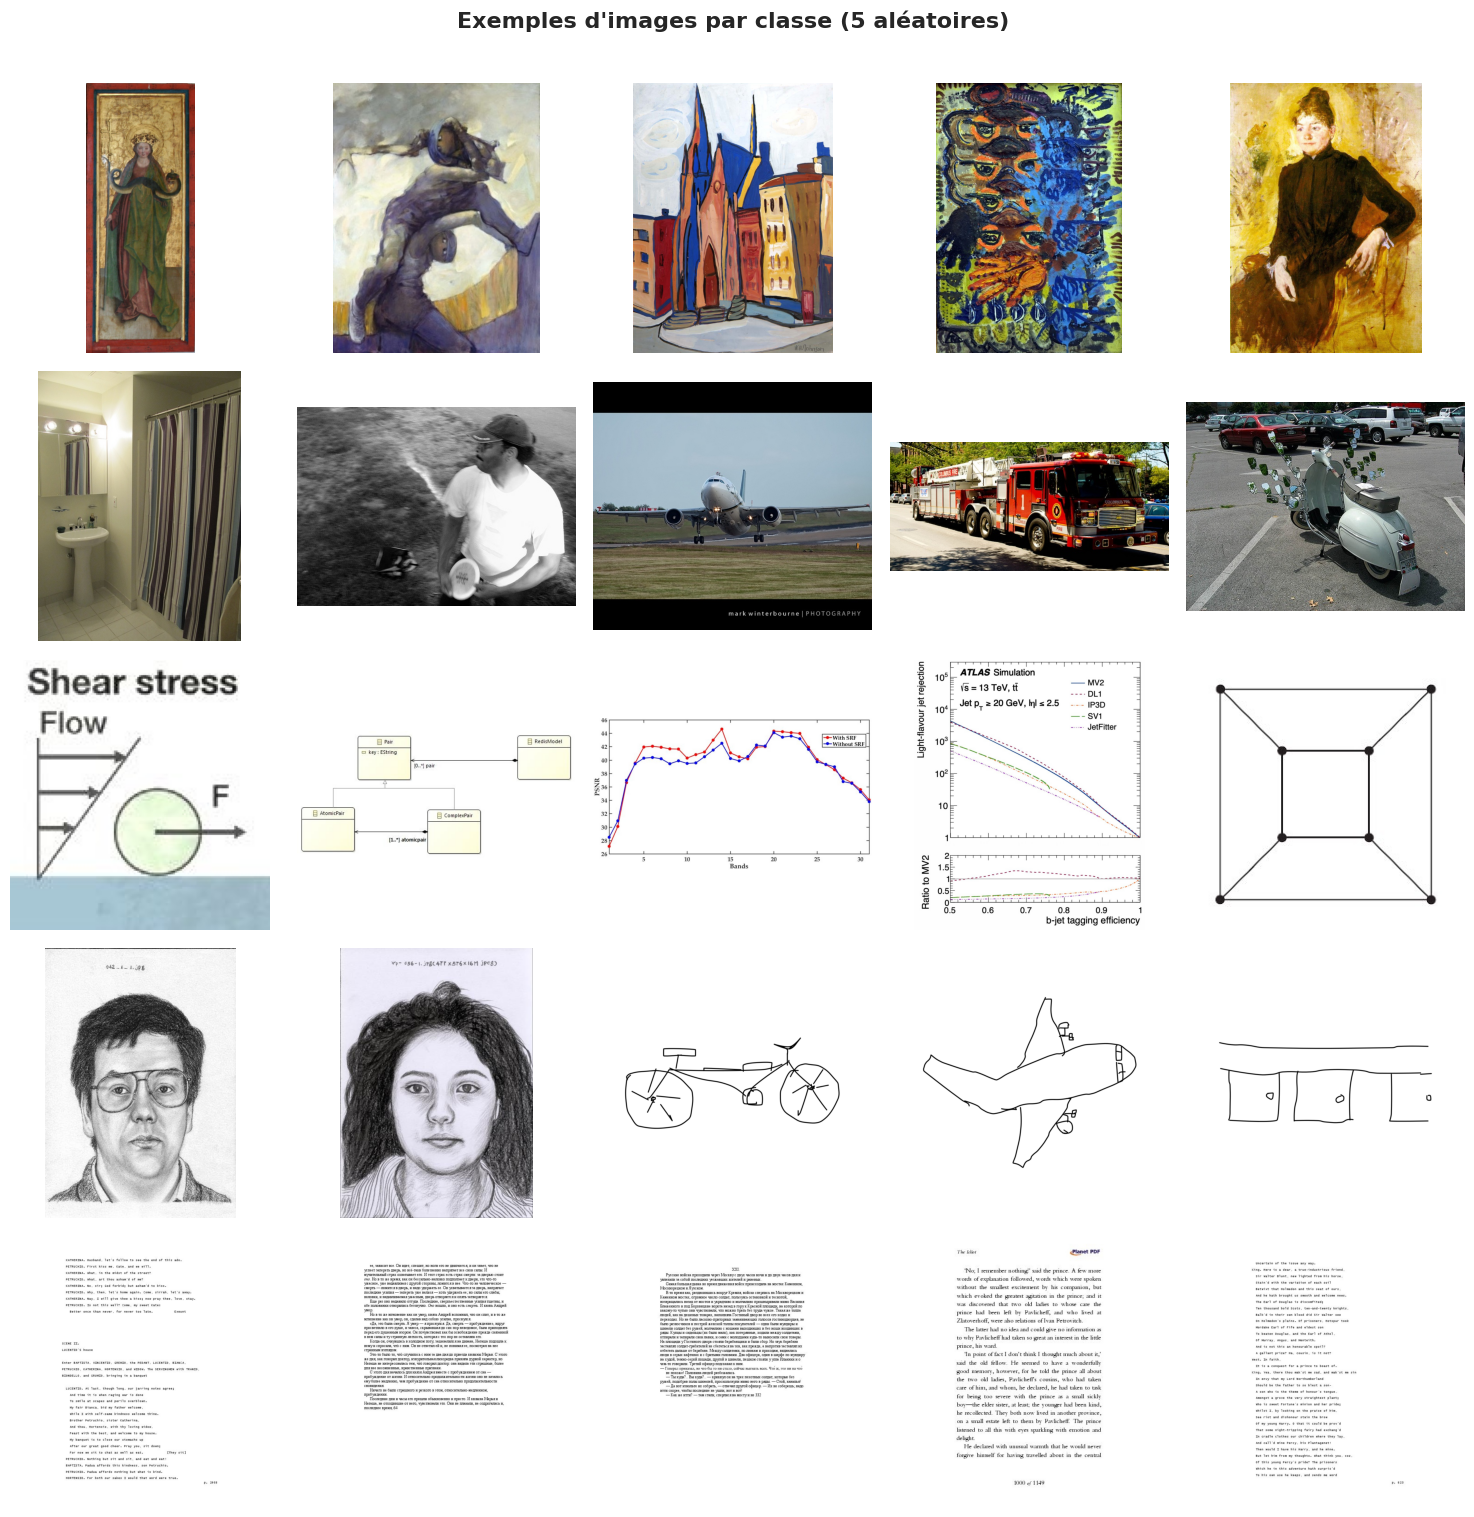

In [5]:
# ============================================================
# EXEMPLES VISUELS PAR CLASSE
# Visualiser quelques images par classe permet de comprendre
# la difficulté de la tâche (ex : peinture réaliste vs photo).
# ============================================================

fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(15, 3 * NUM_CLASSES))
fig.suptitle("Exemples d'images par classe (5 aléatoires)",
             fontsize=16, fontweight='bold', y=1.01)

for i, class_name in enumerate(CLASS_NAMES):
    class_path = os.path.join(DATA_DIR, class_name)
    all_files  = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    # Sélection reproductible de 5 images
    sample_files = np.random.choice(all_files, min(5, len(all_files)), replace=False)

    for j, img_name in enumerate(sample_files):
        img = tf.keras.utils.load_img(os.path.join(class_path, img_name))
        axes[i, j].imshow(np.array(img))
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(class_name, fontsize=12, fontweight='bold',
                                   rotation=0, labelpad=70, ha='right')

plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# ANALYSE DES DIMENSIONS (échantillon de 30 images/classe)
# Utile pour choisir la taille de redimensionnement.
# ============================================================

print("Analyse des dimensions d'un échantillon d'images...\n")

records = []
for class_name in CLASS_NAMES:
    class_path = os.path.join(DATA_DIR, class_name)
    all_files  = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample     = np.random.choice(all_files, min(30, len(all_files)), replace=False)
    for img_name in sample:
        img = tf.keras.utils.load_img(os.path.join(class_path, img_name))
        w, h = img.size
        records.append({'Classe': class_name, 'Largeur': w, 'Hauteur': h, 'Ratio': w / h})

df_dims = pd.DataFrame(records)

print("Statistiques globales des dimensions (pixels) :")
print(df_dims[['Largeur', 'Hauteur']].describe().round(0).astype(int).to_string())
print(f"\nRatio largeur/hauteur médian : {df_dims['Ratio'].median():.2f}")
print(f"\n  Les images seront redimensionnées en {IMG_SIZE[0]}×{IMG_SIZE[1]} pixels.")
print("    Ce format réduit la mémoire et uniformise les entrées du réseau.")

Analyse des dimensions d'un échantillon d'images...

Statistiques globales des dimensions (pixels) :
       Largeur  Hauteur
count      150      150
mean       794      757
std        538      529
min         75       76
25%        562      496
50%        640      644
75%        932      842
max       3701     5490

Ratio largeur/hauteur médian : 1.00

➡️  Les images seront redimensionnées en 128×128 pixels.
    Ce format réduit la mémoire et uniformise les entrées du réseau.


---
## 1b. Nettoyage des Images Corrompues

Certaines images ont des métadonnées JPEG/PNG malformées que le décodeur TensorFlow (strict) rejette.

**Stratégie :**
1. PIL ouvre chaque image avec `LOAD_TRUNCATED_IMAGES = True` (plus tolérant que TF)
2. Si PIL réussit → re-sauvegarde en RGB propre (supprime les métadonnées corrompues)
3. Si PIL échoue → image irrécupérable, déplacée dans `data/_corrupt/`

> Un fichier `.images_cleaned` est créé après le passage pour éviter de tout re-scanner à chaque exécution.

In [7]:
# ============================================================
# NETTOYAGE DES IMAGES CORROMPUES
# ============================================================

from PIL import Image, ImageFile
import shutil
from tqdm.notebook import tqdm

FLAG_FILE = '.images_cleaned'

if os.path.exists(FLAG_FILE):
    print("Images déjà nettoyées (flag .images_cleaned présent). Étape ignorée.")
    print("Supprimez ce fichier pour relancer le nettoyage.")
else:
    # PIL tolérant : peut lire les JPEG tronqués que TF refuse
    ImageFile.LOAD_TRUNCATED_IMAGES = True

    corrupt_dir = os.path.join(DATA_DIR, '_corrupt')
    os.makedirs(corrupt_dir, exist_ok=True)

    # Collecte de tous les fichiers image
    all_files = []
    for cls in CLASS_NAMES:
        cls_dir = os.path.join(DATA_DIR, cls)
        for f in sorted(os.listdir(cls_dir)):
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                all_files.append(os.path.join(cls_dir, f))

    n_ok = n_fixed = n_corrupt = 0

    for img_path in tqdm(all_files, desc="Nettoyage", unit="img"):
        try:
            with Image.open(img_path) as img:
                img.load()          # Force le décodage complet
                rgb = img.convert('RGB')

            # Re-sauvegarde propre : supprime les métadonnées corrompues
            ext = os.path.splitext(img_path)[1].lower()
            fmt = 'JPEG' if ext in ('.jpg', '.jpeg') else 'PNG'
            rgb.save(img_path, format=fmt, quality=95)
            n_fixed += 1

        except Exception:
            # PIL ne peut pas du tout ouvrir cette image → irrécupérable
            dest = os.path.join(corrupt_dir, os.path.basename(img_path))
            shutil.move(img_path, dest)
            n_corrupt += 1

    # Flag pour éviter de relancer à chaque exécution
    open(FLAG_FILE, 'w').close()

    print(f"\n Images re-sauvegardées proprement : {n_fixed:,}")
    print(f" Images irrécupérables (déplacées vers {corrupt_dir}) : {n_corrupt}")
    if n_corrupt > 0:
        print("   → Ces images sont exclues du dataset automatiquement.")
    print("\nRelancez les cellules de chargement du dataset (cell-load-data) maintenant.")

Images déjà nettoyées (flag .images_cleaned présent). Étape ignorée.
Supprimez ce fichier pour relancer le nettoyage.


---
## 2. Préparation des Données

### Stratégie

- **Chargement par batches** avec `image_dataset_from_directory` — évite de charger ~41 000 images en RAM d'un coup
- **Redimensionnement** à 128×128 px (compromis qualité/vitesse)
- **Normalisation** des pixels `[0, 255]` → `[0, 1]` (nécessaire pour la convergence du réseau)
- **Augmentation** sur le train uniquement (enrichit artificiellement les données)
- **Class weights** pour compenser le déséquilibre (classe Sketch sous-représentée)

### Découpage train / val / test

```
Dataset complet (~41 399 images)
         │
    ┌────┴────┐
   80%       20%
  Train   Val + Test
             │
          ┌──┴──┐
         50%   50%
         Val   Test
        (~10%) (~10%)
```

> **Pourquoi un set de test séparé ?**  
> La validation sert à guider l'entraînement (early stopping, lr scheduling).  
> Le test, jamais vu pendant l'entraînement, donne une mesure **non biaisée** des performances réelles.

In [ ]:
# ============================================================
# CHARGEMENT DU DATASET
#
# shuffle=True sur les deux appels est indispensable : sans ça,
# les fichiers sont triés alphabétiquement par classe, et
# take(n_val) ne prendrait que les premières classes (Painting,
# Photo) → val_accuracy = 0%.
# Avec seed=42, le split est reproductible et complémentaire.
# ============================================================

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True,
)

val_test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True,
)

print(f"Classes détectées par TF : {train_ds_raw.class_names}")

n_val_test = tf.data.experimental.cardinality(val_test_ds_raw).numpy()
n_val      = n_val_test // 2
val_ds_raw  = val_test_ds_raw.take(n_val)
test_ds_raw = val_test_ds_raw.skip(n_val)

n_train = tf.data.experimental.cardinality(train_ds_raw).numpy()
n_test  = n_val_test - n_val
print(f"\nBatches  — Train: {n_train} | Val: {n_val} | Test: {n_test}")
print(f"Images ~  — Train: {n_train*BATCH_SIZE:,} | Val: {n_val*BATCH_SIZE:,} | Test: {n_test*BATCH_SIZE:,}")

Found 41399 files belonging to 5 classes.
Using 33120 files for training.
Found 41399 files belonging to 5 classes.
Using 8279 files for validation.
Classes détectées par TF : ['Painting', 'Photo', 'Schematics', 'Sketch', 'Text']

Batches  — Train: 1035 | Val: 129 | Test: 130
Images ~  — Train: 33,120 | Val: 4,128 | Test: 4,160


In [9]:
# ============================================================
# AUGMENTATION DES DONNÉES
# On l'applique UNIQUEMENT sur le set d'entraînement.
#
# Pas de ignore_errors() ici : le nettoyage PIL (cell 07cc88e5)
# a déjà corrigé ou écarté les images corrompues. Sans ignore_errors(),
# la cardinalité du dataset reste CONNUE, ce qui permet à Keras
# d'afficher la progression XX/YY et de recréer l'itérateur
# naturellement à chaque epoch — exactement comme dans le WS.
# ============================================================

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomBrightness(factor=0.15),
    layers.RandomContrast(factor=0.15),
], name="data_augmentation")

rescale  = layers.Rescaling(1.0 / 255.0)
AUTOTUNE = tf.data.AUTOTUNE

def preprocess_train(images, labels):
    images = data_augmentation(images, training=True)
    images = rescale(images)
    return images, labels

def preprocess_eval(images, labels):
    images = rescale(images)
    return images, labels

# Pipeline sans ignore_errors() ni repeat() :
# Keras itère chaque dataset jusqu'à StopIteration (fin naturelle de l'epoch),
# puis recrée un nouvel itérateur pour l'epoch suivante.
train_ds = (train_ds_raw
    .map(preprocess_train, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE))

val_ds = (val_ds_raw
    .map(preprocess_eval, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE))

test_ds = (test_ds_raw
    .map(preprocess_eval, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE))

print("Pipeline configuré :")
print("  train_ds  → augmentation + normalisation")
print("  val_ds    → normalisation")
print("  test_ds   → normalisation")

Pipeline configuré :
  train_ds  → augmentation + normalisation
  val_ds    → normalisation
  test_ds   → normalisation


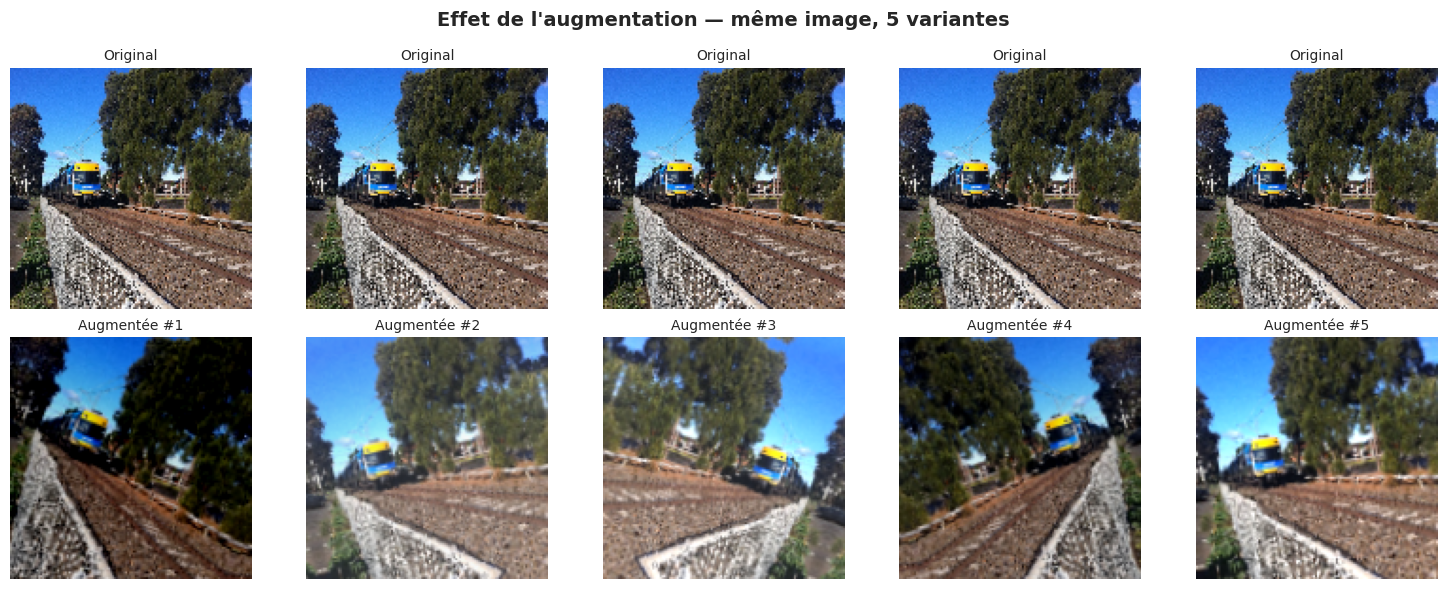

In [10]:
# ============================================================
# VISUALISATION DE L'AUGMENTATION
# On applique l'augmentation sur la même image plusieurs fois
# pour voir la diversité générée.
# ============================================================

# Récupère une image de la classe Photo
photo_dir    = os.path.join(DATA_DIR, 'Photo')
sample_file  = os.listdir(photo_dir)[0]
sample_img   = tf.keras.utils.load_img(os.path.join(photo_dir, sample_file), target_size=IMG_SIZE)
# img_to_array retourne déjà un numpy.ndarray — pas besoin de .numpy()
sample_arr   = tf.keras.utils.img_to_array(sample_img)   # shape (128,128,3), valeurs [0,255]
sample_batch = tf.expand_dims(sample_arr, 0)              # tensor (1,128,128,3) pour le pipeline

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Effet de l'augmentation — même image, 5 variantes",
             fontsize=14, fontweight='bold')

# Ligne 1 : originale (répétée) — sample_arr est un ndarray, .astype suffit
for j in range(5):
    axes[0, j].imshow(sample_arr.astype('uint8'))
    axes[0, j].axis('off')
    axes[0, j].set_title('Original', fontsize=10)

# Ligne 2 : versions augmentées — le résultat de data_augmentation est un tensor TF
for j in range(5):
    aug = data_augmentation(sample_batch, training=True)[0]
    aug = tf.clip_by_value(aug, 0, 255).numpy().astype('uint8')
    axes[1, j].imshow(aug)
    axes[1, j].axis('off')
    axes[1, j].set_title(f'Augmentée #{j+1}', fontsize=10)

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# CLASS WEIGHTS — Compensation du déséquilibre de classes
# Formule : weight_i = (N_total / N_classes) / N_i
# ============================================================

from tqdm.notebook import tqdm

label_counts = np.zeros(NUM_CLASSES, dtype=np.int64)

for _, labels in tqdm(train_ds_raw, total=n_train, desc="Comptage des labels"):
    for label in labels.numpy():
        label_counts[label] += 1

n_total       = label_counts.sum()
class_weights = {
    i: n_total / (NUM_CLASSES * count)
    for i, count in enumerate(label_counts)
}

print(f"\n{'Idx':<5} {'Classe':<15} {'Images':>8} {'Weight':>9}")
print("-" * 42)
for i, (cls, cnt) in enumerate(zip(CLASS_NAMES, label_counts)):
    print(f"{i:<5} {cls:<15} {cnt:>8,} {class_weights[i]:>9.3f}")
print(f"\nLa classe '{CLASS_NAMES[max(class_weights, key=class_weights.get)]}' "
      f"a le poids le plus élevé ({max(class_weights.values()):.3f}).")

Comptage des labels:   0%|          | 0/1035 [00:00<?, ?it/s]


Idx   Classe            Images    Weight
------------------------------------------
0     Painting           8,003     0.828
1     Photo              7,971     0.831
2     Schematics         7,940     0.834
3     Sketch             1,148     5.770
4     Text               8,058     0.822

La classe 'Sketch' a le poids le plus élevé (5.770).


---
## 3. Architecture du Réseau de Neurones

### Pourquoi un CNN ?

Les **Réseaux de Neurones Convolutifs (CNN)** sont l'architecture de référence pour la classification d'images :
- Les **filtres de convolution** détectent automatiquement des caractéristiques spatiales (bords, textures, formes)
- Le **partage des poids** rend le modèle efficace en paramètres
- L'**invariance à la translation** (via MaxPooling) améliore la généralisation

### Architecture choisie — CNN à 4 blocs convolutifs

Inspirée de VGGNet, notre architecture empile des blocs `Conv → BatchNorm → ReLU → MaxPool → Dropout`,
avec une profondeur croissante des filtres (32 → 64 → 128 → 256) :

```
INPUT  (128 × 128 × 3)
  │
  ├─► BLOC 1 ─── Conv2D(32) × 2 → BN → ReLU → MaxPool(2×2) → Drop(0.25)
  │              Sortie : 64 × 64 × 32   — détection : bords, gradients de couleur
  │
  ├─► BLOC 2 ─── Conv2D(64) × 2 → BN → ReLU → MaxPool(2×2) → Drop(0.25)
  │              Sortie : 32 × 32 × 64   — détection : textures, motifs locaux
  │
  ├─► BLOC 3 ─── Conv2D(128) × 2 → BN → ReLU → MaxPool(2×2) → Drop(0.25)
  │              Sortie : 16 × 16 × 128  — détection : formes complexes
  │
  ├─► BLOC 4 ─── Conv2D(256) → BN → ReLU → MaxPool(2×2) → Drop(0.25)
  │              Sortie : 8 × 8 × 256    — sémantique globale
  │
  ├─► GlobalAveragePooling2D  →  1 × 256
  │
  ├─► Dense(512) → BN → ReLU → Dropout(0.5)
  │
  └─► Dense(5, softmax)  →  probabilités pour 5 classes
```

### Justification des composants

| Composant | Rôle |
|-----------|------|
| **Conv2D** | Extraction de features par filtres apprenants |
| **BatchNormalization** | Stabilise l'entraînement, accélère la convergence |
| **ReLU** | Introduit la non-linéarité (sans saturer le gradient) |
| **MaxPooling2D** | Réduit la résolution, renforce l'invariance |
| **Dropout** | Régularisation — force le réseau à ne pas dépendre de neurones spécifiques |
| **GlobalAveragePooling** | Alternative plus légère au Flatten — réduit le risque de surapprentissage |
| **Softmax** | Convertit les scores bruts en probabilités (somme = 1) |

In [12]:
# ============================================================
# CONSTRUCTION DU MODÈLE CNN
# ============================================================

def build_cnn(input_shape=(128, 128, 3), num_classes=5, dropout_conv=0.25, dropout_dense=0.5):
    """
    Construit le CNN à 4 blocs convolutifs.

    Args:
        input_shape   : dimensions d'une image (H, W, C)
        num_classes   : nombre de classes à prédire
        dropout_conv  : taux de dropout après chaque bloc convolutif
        dropout_dense : taux de dropout avant la couche de sortie
    """
    model = models.Sequential(name="CNN_TouNum")
    model.add(layers.Input(shape=input_shape))

    # ---- Bloc 1 : bords et gradients de couleur (filtres 32) ----
    for _ in range(2):
        model.add(layers.Conv2D(32, (3, 3), padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(dropout_conv))

    # ---- Bloc 2 : textures et motifs locaux (filtres 64) ----
    for _ in range(2):
        model.add(layers.Conv2D(64, (3, 3), padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(dropout_conv))

    # ---- Bloc 3 : formes complexes (filtres 128) ----
    for _ in range(2):
        model.add(layers.Conv2D(128, (3, 3), padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(dropout_conv))

    # ---- Bloc 4 : représentations sémantiques (filtres 256) ----
    model.add(layers.Conv2D(256, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(dropout_conv))

    # ---- Classifieur ----
    # GlobalAveragePooling calcule la moyenne spatiale de chaque feature map
    # (plus robuste que Flatten contre le surapprentissage)
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(512))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(dropout_dense))

    # ---- Couche de sortie ----
    # Softmax : transforme les logits en probabilités (somme = 1)
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model


model = build_cnn(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES)
model.summary()

Model: "CNN_TouNum"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_72 (Conv2D)          (None, 128, 128, 32)      896       
                                                                 
 batch_normalization_81 (Ba  (None, 128, 128, 32)      128       
 tchNormalization)                                               
                                                                 
 activation (Activation)     (None, 128, 128, 32)      0         
                                                                 
 conv2d_73 (Conv2D)          (None, 128, 128, 32)      9248      
                                                                 
 batch_normalization_82 (Ba  (None, 128, 128, 32)      128       
 tchNormalization)                                               
                                                                 
 activation_1 (Activation)   (None, 128, 128, 32)      0

In [13]:
# ============================================================
# COMPILATION DU MODÈLE
#
# Optimizer Adam  : adaptatif, robuste, peu sensible au learning rate initial
# Loss            : sparse_categorical_crossentropy
#                   (labels entiers → pas besoin de one-hot encoding)
# Metric accuracy : proportion d'images correctement classifiées
# ============================================================

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

# Vérification : passe un batch fictif pour valider les shapes
dummy = tf.zeros((1, *IMG_SIZE, 3))
out   = model(dummy, training=False)
print(f"Shape de sortie : {out.shape}  — somme des probabilités : {out.numpy().sum():.6f}")
print("Modèle compilé et prêt pour l'entraînement.")

Shape de sortie : (1, 5)  — somme des probabilités : 1.000000
Modèle compilé et prêt pour l'entraînement.


---
## 4. Entraînement <a id="4"></a>

### Stratégie d'optimisation

L'entraînement utilise l'optimiseur **Adam** (Adaptive Moment Estimation), qui adapte
automatiquement le taux d'apprentissage pour chaque paramètre. C'est le choix standard
pour les CNN car il converge rapidement et tolère bien des hyperparamètres non parfaits.

### Callbacks

Trois mécanismes automatiques pilotent et sécurisent l'entraînement :

| Callback | Paramètres | Rôle |
|----------|-----------|------|
| **EarlyStopping** | `patience=8` | Arrête si `val_loss` ne baisse plus pendant 8 epochs consécutives. Restaure automatiquement les poids du meilleur epoch. |
| **ReduceLROnPlateau** | `patience=3`, `factor=0.5` | Divise le learning rate par 2 après 3 epochs sans amélioration. Affine la convergence quand le modèle est proche de l'optimum. |
| **ModelCheckpoint** | `monitor=val_accuracy` | Sauvegarde le modèle **uniquement** quand `val_accuracy` s'améliore — garantit de conserver le meilleur état. |

### Pourquoi ces valeurs ?

- **patience=8** pour EarlyStopping : suffisamment tolérant pour que ReduceLROnPlateau ait le temps de réduire le LR et relancer la descente.
- **patience=3** pour ReduceLR : déclenche tôt pour ne pas gaspiller d'epochs à un LR trop élevé.
- **factor=0.5** : diviser par 2 est un compromis — pas trop agressif (÷10) ni trop timide (÷1.1).

### Mécanisme anti-surapprentissage intégré

```
Epoch k : val_loss diminue → continue
Epoch k+1..k+3 : val_loss stagne → ReduceLR divise le LR par 2
Epoch k+4..k+8 : val_loss stagne encore → EarlyStopping déclenche
→ Les meilleurs poids (epoch k) sont restaurés automatiquement
```


In [14]:
# ============================================================
# CALLBACKS
# ============================================================

callbacks = [
    # Arrête l'entraînement si val_loss ne baisse plus pendant 8 epochs
    # → laisse le temps à ReduceLROnPlateau d'agir (patience=3) avant de stopper
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1,
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),

    # save_format='h5' forcé explicitement — le format .keras natif de TF 2.14
    # passe un argument 'options' non supporté et lève une ValueError
    keras.callbacks.ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        save_format='h5',
        verbose=1,
    ),
]

print("Callbacks configurés :")
for cb in callbacks:
    print(f"  - {cb.__class__.__name__}")
print(f"  Modèle sauvegardé dans : {MODEL_SAVE_PATH}")

Callbacks configurés :
  - EarlyStopping
  - ReduceLROnPlateau
  - ModelCheckpoint
  Modèle sauvegardé dans : ./model_classification.h5


In [15]:
# ============================================================
# ENTRAÎNEMENT
#
# Pas de steps_per_epoch ni validation_steps : Keras itère
# chaque dataset jusqu'à épuisement naturel (comme dans le WS).
# La cardinalité est connue → progression XX/YY affichée.
# ============================================================

print("Début de l'entraînement...")
print(f"  Taille image   : {IMG_SIZE}")
print(f"  Batch size     : {BATCH_SIZE}")
print(f"  Epochs max     : {EPOCHS}")
print(f"  Learning rate  : {LEARNING_RATE}")
print("-" * 50)

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)

print(f"\nEntraînement terminé. Meilleur modèle sauvegardé : {MODEL_SAVE_PATH}")

Début de l'entraînement...
  Taille image   : (128, 128)
  Batch size     : 32
  Epochs max     : 30
  Learning rate  : 0.0001
--------------------------------------------------
Epoch 1/30


2026-05-26 12:18:26.497828: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inCNN_TouNum/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1035/1035 [==============================] - ETA: 0s - loss: 0.2302 - accuracy: 0.8933
Epoch 1: val_accuracy improved from -inf to 0.81516, saving model to ./model_classification.h5
1035/1035 [==============================] - 112s 101ms/step - loss: 0.2302 - accuracy: 0.8933 - val_loss: 0.5017 - val_accuracy: 0.8152 - lr: 2.5000e-05
Epoch 2/30
1035/1035 [==============================] - ETA: 0s - loss: 0.2288 - accuracy: 0.8946
Epoch 2: val_accuracy did not improve from 0.81516
1035/1035 [==============================] - 100s 96ms/step - loss: 0.2288 - accuracy: 0.8946 - val_loss: 0.4974 - val_accuracy: 0.8127 - lr: 2.5000e-05
Epoch 3/30
1035/1035 [==============================] - ETA: 0s - loss: 0.2226 - accuracy: 0.8973
Epoch 3: val_accuracy improved from 0.81516 to 0.83915, saving model to ./model_classification.h5
1035/1035 [==============================] - 105s 101ms/step - loss: 0.2226 - accuracy: 0.8973 - val_loss: 0.4390 - val_accuracy: 0.8391 - lr: 2.5000e-05
Epoch 4/30
1

---
## 5. Analyse des Résultats <a id="5"></a>

### Courbes d'apprentissage

Les courbes **train vs validation** sont l'outil principal pour diagnostiquer l'état de l'apprentissage.
On les lit en cherchant trois patterns :

```
  Accuracy
     │
  1  ├── train  ──────────────────────
     │   val    ─────────────────────   ← Bon équilibre : courbes proches et hautes 
     │
     │   train  ──────────────────────
     │   val    ────────                ← Surapprentissage : écart croissant entre train et val
     │
     │   train  ──────
     │   val    ──────                  ← Sous-apprentissage : les deux sont basses
     │
  0  └──────────────────────────────► Epochs
```

### Matrice de confusion

La matrice de confusion montre **ce que le modèle confond** :
- Diagonale = prédictions correctes (on veut maximiser)
- Hors-diagonale = erreurs (on veut minimiser)
- La version **normalisée** (rappel) révèle les classes les plus difficiles indépendamment du nombre d'images

### Métriques par classe

| Métrique | Formule | Interprétation |
|----------|---------|---------------|
| **Précision** | TP / (TP + FP) | Parmi les images prédites comme classe X, combien le sont vraiment ? |
| **Rappel** | TP / (TP + FN) | Parmi les vraies images de classe X, combien sont correctement détectées ? |
| **F1-score** | 2 × P × R / (P + R) | Équilibre entre précision et rappel — utile quand les classes sont déséquilibrées |


---
### Reprise après restart du kernel

> **Note :** Si le kernel a été redémarré (arrêt du conteneur Docker, fermeture du navigateur, etc.),
> les variables Python sont perdues mais le modèle sauvegardé sur disque persiste.
> La cellule ci-dessous recharge le modèle directement depuis `model_classification.h5`
> — inutile de ré-entraîner.


In [ ]:
# ============================================================
# REPRISE RAPIDE — après un restart du container Docker
#
# Le kernel Python repart à zéro : les variables (model, history,
# train_ds…) sont perdues. Mais model_classification.h5 est sur
# le volume Docker → il persiste entre les sessions.
#
# Pour évaluer/utiliser le modèle sans ré-entraîner, exécutez
# dans l'ordre :
#   1. cell-imports      (imports)
#   2. cell-config       (chemins, CLASS_NAMES, IMG_SIZE…)
#   3. cell-load-data    (reconstruction des datasets)
#   4. cell-augmentation (reconstruction des pipelines)
#   5. CETTE cellule     (chargement du modèle sauvegardé)
#   6. cell-eval / cell-confusion / cell-gui  (analyses)
#
# Note : cell-curves nécessite l'objet `history` qui n'existe
# qu'après un vrai entraînement — elle ne peut pas être relancée
# après restart sans re-lancer cell-fit.
# ============================================================

if os.path.exists(MODEL_SAVE_PATH):
    model = keras.models.load_model(MODEL_SAVE_PATH)
    print(f"Modèle chargé depuis : {MODEL_SAVE_PATH}")
    print(f"Architecture : {model.input_shape} → {model.output_shape}")
else:
    print(f"Aucun modèle trouvé à '{MODEL_SAVE_PATH}'.")
    print("Relancez l'entraînement complet (cell-build-model → cell-compile → cell-fit).")

Modèle chargé depuis : ./model_classification.h5
Architecture : (None, 128, 128, 3) → (None, 5)


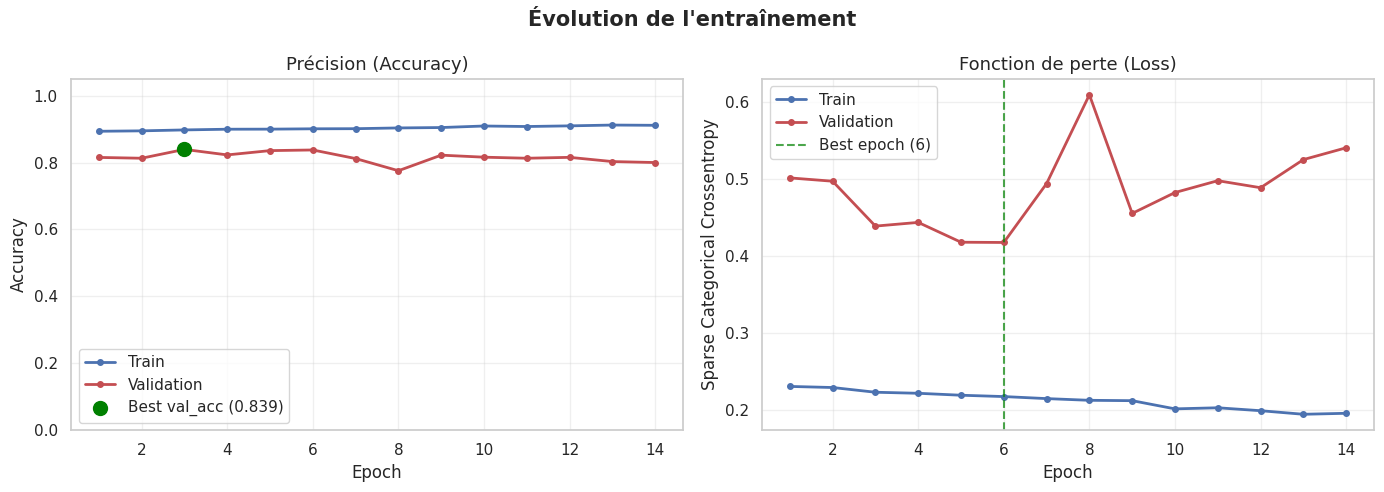


📊 Résumé :
  Epochs effectuées  : 14
  Meilleure val_acc  : 0.8391 (83.91%) à l'epoch 3
  Dernière train_acc : 0.9111
  Dernière val_acc   : 0.7999
  Écart train/val    : 0.1112  → ✅ Apprentissage stable


In [16]:
# ============================================================
# COURBES D'ENTRAÎNEMENT
# ============================================================

def plot_history(history):
    """Affiche les courbes loss et accuracy (train vs validation)."""
    epochs_ran = range(1, len(history.history['loss']) + 1)

    fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Évolution de l'entraînement", fontsize=15, fontweight='bold')

    # -- Courbe Accuracy --
    ax2.plot(epochs_ran, history.history['accuracy'],     'b-o', ms=4, lw=2, label='Train')
    ax2.plot(epochs_ran, history.history['val_accuracy'], 'r-o', ms=4, lw=2, label='Validation')
    best_acc_epoch = int(np.argmax(history.history['val_accuracy'])) + 1
    best_acc       = max(history.history['val_accuracy'])
    ax2.scatter([best_acc_epoch], [best_acc], color='green', zorder=5, s=100,
                label=f'Best val_acc ({best_acc:.3f})')
    ax2.set_title('Précision (Accuracy)', fontsize=13)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0, 1.05)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # -- Courbe Loss --
    ax1.plot(epochs_ran, history.history['loss'],     'b-o', ms=4, lw=2, label='Train')
    ax1.plot(epochs_ran, history.history['val_loss'], 'r-o', ms=4, lw=2, label='Validation')
    best_epoch = int(np.argmin(history.history['val_loss'])) + 1
    ax1.axvline(best_epoch, color='green', ls='--', alpha=0.7, label=f'Best epoch ({best_epoch})')
    ax1.set_title('Fonction de perte (Loss)', fontsize=13)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Sparse Categorical Crossentropy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)


    plt.tight_layout()
    plt.show()

    # Résumé chiffré
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc   = history.history['val_accuracy'][-1]
    gap             = final_train_acc - final_val_acc

    print(f"\n📊 Résumé :")
    print(f"  Epochs effectuées  : {len(epochs_ran)}")
    print(f"  Meilleure val_acc  : {best_acc:.4f} ({best_acc*100:.2f}%) à l'epoch {best_acc_epoch}")
    print(f"  Dernière train_acc : {final_train_acc:.4f}")
    print(f"  Dernière val_acc   : {final_val_acc:.4f}")
    print(f"  Écart train/val    : {gap:.4f}", end="  ")
    if gap > 0.15:
        print("→   Surapprentissage probable")
    elif final_val_acc < 0.70:
        print("→   Sous-apprentissage probable")
    else:
        print("→  Apprentissage stable")


plot_history(history)

In [17]:
# ============================================================
# ÉVALUATION FINALE SUR LE SET DE TEST
# Le test set n'a jamais été vu pendant l'entraînement ni les callbacks
# → mesure non biaisée des performances en production.
# ============================================================

test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print("Performance sur le set de TEST (données jamais vues) :")
print(f"  Accuracy : {test_acc*100:.2f}%")
print(f"  Loss     : {test_loss:.4f}")

Performance sur le set de TEST (données jamais vues) :
  Accuracy : 83.18%
  Loss     : 0.4733


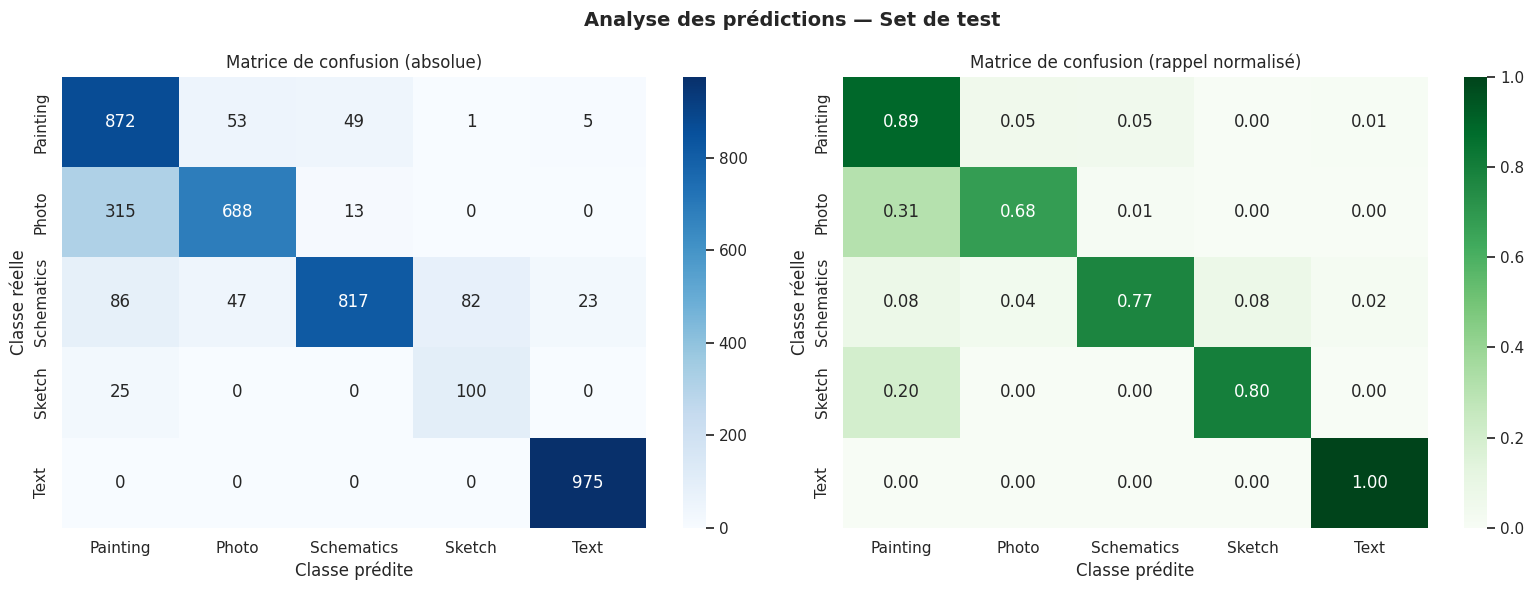


Rapport de classification :

Classe           Précision    Rappel   F1-score   Support
------------------------------------------------------------
Painting             0.672     0.890      0.766       980
Photo                0.873     0.677      0.763     1,016
Schematics           0.929     0.774      0.845     1,055
Sketch               0.546     0.800      0.649       125
Text                 0.972     1.000      0.986       975
------------------------------------------------------------
Accuracy globale      0.832


In [22]:
# ============================================================
# MATRICE DE CONFUSION ET MÉTRIQUES PAR CLASSE
# ============================================================

# Synchronisation : CLASS_NAMES doit correspondre aux sorties du modèle.
# model.output_shape[-1] est la source de vérité (nombre de neurones softmax).
n_cls = model.output_shape[-1]
CLASS_NAMES = CLASS_NAMES[:n_cls]   # coupe les classes parasites si nécessaire

# Collecte des prédictions sur tout le set de test
y_true_list, y_pred_list = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred_list.extend(np.argmax(preds, axis=1))
    y_true_list.extend(labels.numpy())

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)

# Calcul de la matrice de confusion (n_cls × n_cls)
cm = np.zeros((n_cls, n_cls), dtype=int)
for t, p in zip(y_true, y_pred):
    if t < n_cls and p < n_cls:   # garde-fou contre les labels hors plage
        cm[t][p] += 1

# --- Visualisation ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Analyse des prédictions — Set de test", fontsize=14, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax1)
ax1.set_title('Matrice de confusion (absolue)')
ax1.set_xlabel('Classe prédite')
ax1.set_ylabel('Classe réelle')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', vmin=0, vmax=1,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax2)
ax2.set_title('Matrice de confusion (rappel normalisé)')
ax2.set_xlabel('Classe prédite')
ax2.set_ylabel('Classe réelle')

plt.tight_layout()
plt.show()

# --- Rapport de classification ---
print("\nRapport de classification :")
print(f"\n{'Classe':<15} {'Précision':>10} {'Rappel':>9} {'F1-score':>10} {'Support':>9}")
print("-" * 60)

for i, cls in enumerate(CLASS_NAMES):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    # Précision : parmi les images prédites comme classe i, combien le sont vraiment ?
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    # Rappel : parmi les vraies images de classe i, combien sont correctement détectées ?
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    # F1 : moyenne harmonique de précision et rappel — équilibre les deux métriques
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    support   = int(cm[i, :].sum())
    print(f"{cls:<15} {precision:>10.3f} {recall:>9.3f} {f1:>10.3f} {support:>9,}")

print("-" * 60)
overall_acc = cm.diagonal().sum() / cm.sum()
print(f"{'Accuracy globale':<15} {overall_acc:>10.3f}")

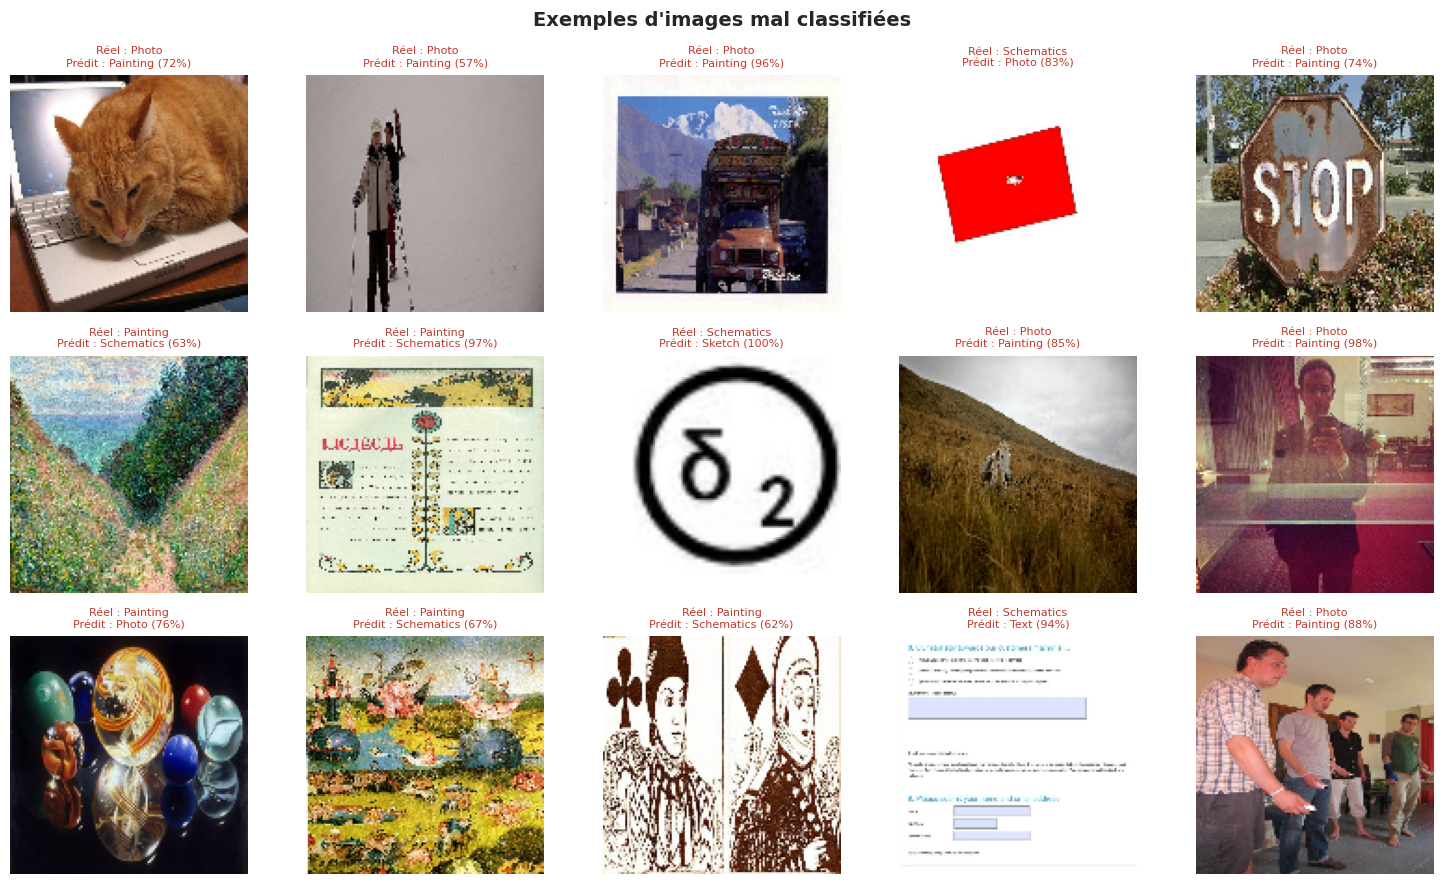

Total d'erreurs collectées : 15


In [23]:
# ============================================================
# EXEMPLES D'ERREURS
# Visualiser les images mal classifiées aide à comprendre
# les limites du modèle et à trouver des pistes d'amélioration.
# ============================================================

errors = []
for images, labels in test_ds:
    preds         = model.predict(images, verbose=0)
    pred_classes  = np.argmax(preds, axis=1)
    for i in range(len(labels)):
        if pred_classes[i] != labels[i]:
            errors.append({
                'image': images[i].numpy(),
                'true':  int(labels[i].numpy()),
                'pred':  int(pred_classes[i]),
                'conf':  float(preds[i][pred_classes[i]]),
            })
    if len(errors) >= 15:
        break

if errors:
    n_show = min(15, len(errors))
    fig, axes = plt.subplots(3, 5, figsize=(15, 9))
    fig.suptitle("Exemples d'images mal classifiées", fontsize=14, fontweight='bold')

    for idx, ax in enumerate(axes.flatten()):
        if idx < n_show:
            err = errors[idx]
            ax.imshow(np.clip(err['image'], 0, 1))
            ax.set_title(
                f"Réel : {CLASS_NAMES[err['true']]}\n"
                f"Prédit : {CLASS_NAMES[err['pred']]} ({err['conf']*100:.0f}%)",
                fontsize=8, color='#c0392b'
            )
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    print(f"Total d'erreurs collectées : {len(errors)}")
else:
    print("Aucune erreur à afficher sur ce sous-ensemble.")

---
## 6. Analyse Biais / Variance

Le dilemme **biais/variance** est central en Machine Learning. Il décrit le compromis entre deux types d'erreurs opposées.

### 📉 Sous-apprentissage (Biais élevé)

Le modèle est **trop simple** pour capturer les patterns des données.

- **Symptômes** : accuracy d'entraînement **et** de validation toutes deux faibles
- **Causes** : architecture trop petite, trop peu d'epochs, learning rate inadapté
- **Solutions** : augmenter la capacité du modèle, entraîner plus longtemps

### 📈 Surapprentissage (Variance élevée)

Le modèle **mémorise** les données d'entraînement au lieu d'apprendre des patterns généraux.

- **Symptômes** : accuracy train élevée, accuracy validation bien inférieure (grand écart)
- **Causes** : modèle trop grand, données insuffisantes, absence de régularisation
- **Solutions** : dropout, data augmentation, early stopping, régularisation L2

### 📊 Lecture des courbes d'apprentissage

```
 Accuracy
    │
 1  │    train ──────────────────────────
    │    val   ────────────────────────── ← bon équilibre : courbes proches 
    │
    │    train ────────────────────
    │    val   ─────────                  ← surapprentissage : écart croissant
    │
 0  │    train ─────                      ← sous-apprentissage : les deux basses
    │    val   ─────
    └─────────────────────────────────► Epochs
```

### Dans notre modèle

Plusieurs mécanismes limitent le surapprentissage :

| Mécanisme | Effet |
|-----------|-------|
| **Dropout (0.25 / 0.5)** | Force le réseau à apprendre des représentations redondantes |
| **BatchNormalization** | Régularise implicitement en réduisant la dépendance entre couches |
| **Data augmentation** | Chaque image est légèrement différente à chaque epoch |
| **EarlyStopping** | Arrête avant la phase de mémorisation |
| **Class weights** | Évite que le modèle « triche » en ignorant les classes rares |

---
## 7. Pistes d'Amélioration

### Techniques de régularisation supplémentaires

| Technique | Description | Utilisation |
|-----------|-------------|-------------|
| **Régularisation L2** | Pénalise les poids trop grands dans les couches Dense | `Dense(512, kernel_regularizer=l2(1e-4))` |
| **Label Smoothing** | Atténue la confiance du modèle sur les labels | `SparseCategoricalCrossentropy(label_smoothing=0.1)` |
| **Mixup / CutMix** | Mélange deux images pendant l'entraînement | Augmentation avancée |

### Architectures alternatives

Le **Transfer Learning** exploite des réseaux pré-entraînés sur ImageNet (1,4M images, 1000 classes).
Les couches basses ont déjà appris des features génériques (bords, textures) — on ré-entraîne
uniquement les couches hautes sur notre dataset :

```python
# Exemple avec MobileNetV2 (léger, performant)
base = tf.keras.applications.MobileNetV2(input_shape=(*IMG_SIZE, 3),
                                          include_top=False, weights='imagenet')
base.trainable = False   # Gèle les couches pré-entraînées

x = base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
```

Gain attendu : **+10 à +20% d'accuracy** avec moins d'epochs d'entraînement.

### Amélioration des données

- **Oversampling de Sketch** : générer plus d'images via augmentation agressive
- **Collecte de données** : ajouter plus d'images dans les classes difficiles (peintures réalistes)
- **Nettoyage** : vérifier que chaque image est bien dans la bonne classe (labelling errors)

---
## 7b. Comparaison — Architecture Externe fakv8

### Analyse des différences

| Critère | Mon CNN (livrable 1) | fakv8 |
|---------|---------------------|-------|
| **Taille images** | 128×128 px | **256×256 px** (4× plus de pixels) |
| **Batch size** | 32 | 16 |
| **Bloc 4** | Conv(256) × 1 | **Conv(256) × 2** (plus profond) |
| **Dropout convolutif** | 0.25 (fixe) | **0.2→0.2→0.3→0.4** (progressif) |
| **Learning rate** | 1e-4 | **3e-4** (3× plus élevé) |
| **EarlyStopping patience** | 8 epochs | 12 epochs |
| **Params estimés** | ~720K | ~2.8M |

### Prédiction

**fakv8 devrait gagner +1 à +4%** grâce à :
1. **Images 256×256** : plus de détail pour discriminer Painting/Photo
2. **Bloc 4 plus profond** : 2 convolutions → représentations plus riches
3. **Dropout progressif** : régularisation plus forte dans les couches profondes

**Contreparties** : entraînement ~2× plus lent, plus de VRAM, LR plus élevé (peut être moins stable).

In [ ]:
# ============================================================
# DONNÉES POUR FAKV8 — chargement à 256×256
# fakv8 utilise des images 4× plus grandes que notre CNN.
# On recharge le même dataset avec cette résolution.
# ============================================================

FAKV8_IMG_SIZE  = (256, 256)
FAKV8_BATCH     = 16
FAKV8_SAVE_PATH = './fakv8_test_model.h5'

train_ds_fak_raw = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=VAL_SPLIT, subset="training",
    seed=42, image_size=FAKV8_IMG_SIZE, batch_size=FAKV8_BATCH, label_mode='int', shuffle=True,
)
val_test_ds_fak_raw = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=VAL_SPLIT, subset="validation",
    seed=42, image_size=FAKV8_IMG_SIZE, batch_size=FAKV8_BATCH, label_mode='int', shuffle=True,
)

n_vt_fak    = tf.data.experimental.cardinality(val_test_ds_fak_raw).numpy()
n_val_fak   = n_vt_fak // 2
val_ds_fak_raw  = val_test_ds_fak_raw.take(n_val_fak)
test_ds_fak_raw = val_test_ds_fak_raw.skip(n_val_fak)

# Augmentation identique à fakv8.py (flip + rotation 0.15 + zoom 0.15)
data_aug_fak = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
], name="aug_fakv8")

rescale_fak = layers.Rescaling(1.0 / 255.0)

def preprocess_fak_train(images, labels):
    return rescale_fak(data_aug_fak(images, training=True)), labels

def preprocess_fak_eval(images, labels):
    return rescale_fak(images), labels

train_ds_fak = train_ds_fak_raw.map(preprocess_fak_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds_fak   = val_ds_fak_raw.map(preprocess_fak_eval,   num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds_fak  = test_ds_fak_raw.map(preprocess_fak_eval,  num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

n_tr_fak = tf.data.experimental.cardinality(train_ds_fak_raw).numpy()
n_te_fak = n_vt_fak - n_val_fak
print(f"Dataset 256×256 — Train: {n_tr_fak} batches | Val: {n_val_fak} | Test: {n_te_fak}")
print(f"Images ~         — Train: {n_tr_fak*FAKV8_BATCH:,} | Val: {n_val_fak*FAKV8_BATCH:,}")

Found 41399 files belonging to 5 classes.
Using 33120 files for training.
Found 41399 files belonging to 5 classes.
Using 8279 files for validation.
Dataset 256×256 — Train: 2070 batches | Val: 259 | Test: 259
Images ~         — Train: 33,120 | Val: 4,144


In [ ]:
# ============================================================
# ARCHITECTURE fakv8
# Différences clés vs mon CNN :
#   - Input 256×256 (4× plus de pixels)
#   - Bloc 4 : 2 convolutions au lieu de 1
#   - Dropout progressif par bloc (0.2→0.2→0.3→0.4)
#   - Activation intégrée dans Conv2D (style original fakv8)
# ============================================================

def build_fakv8(input_shape=(256, 256, 3), num_classes=5):
    m = models.Sequential(name="CNN_fakv8")
    m.add(layers.Input(shape=input_shape))

    # Bloc 1 — 32 filtres, dropout 0.2
    for _ in range(2):
        m.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
        m.add(layers.BatchNormalization())
    m.add(layers.MaxPooling2D(2, 2))
    m.add(layers.Dropout(0.2))

    # Bloc 2 — 64 filtres, dropout 0.2
    for _ in range(2):
        m.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
        m.add(layers.BatchNormalization())
    m.add(layers.MaxPooling2D(2, 2))
    m.add(layers.Dropout(0.2))

    # Bloc 3 — 128 filtres, dropout 0.3
    for _ in range(2):
        m.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
        m.add(layers.BatchNormalization())
    m.add(layers.MaxPooling2D(2, 2))
    m.add(layers.Dropout(0.3))

    # Bloc 4 — 256 filtres × 2, dropout 0.4  ← 2 convs vs 1 dans mon CNN
    for _ in range(2):
        m.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
        m.add(layers.BatchNormalization())
    m.add(layers.MaxPooling2D(2, 2))
    m.add(layers.Dropout(0.4))

    # Classifieur
    m.add(layers.GlobalAveragePooling2D())
    m.add(layers.Dense(512, activation='relu'))
    m.add(layers.BatchNormalization())
    m.add(layers.Dropout(0.5))
    m.add(layers.Dense(num_classes, activation='softmax'))
    return m


model_fak = build_fakv8(input_shape=(*FAKV8_IMG_SIZE, 3), num_classes=NUM_CLASSES)

model_fak.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

model_fak.summary()

dummy_fak = tf.zeros((1, *FAKV8_IMG_SIZE, 3))
print(f"\nShape de sortie : {model_fak(dummy_fak, training=False).shape}")

Model: "CNN_fakv8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 256, 256, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 256, 256, 32)      128       
 Normalization)                                                  
                                                                 
 conv2d_1 (Conv2D)           (None, 256, 256, 32)      9248      
                                                                 
 batch_normalization_1 (Bat  (None, 256, 256, 32)      128       
 chNormalization)                                                
                                                                 
 max_pooling2d (MaxPooling2  (None, 128, 128, 32)      0         
 D)                                                              
                                                         

In [ ]:
# ============================================================
# ENTRAÎNEMENT fakv8
# Hyperparamètres fidèles à fakv8.py :
#   LR = 3e-4 | EarlyStopping patience=12 | ReduceLR patience=4
# ============================================================

callbacks_fak = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=12,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=FAKV8_SAVE_PATH,
        monitor='val_loss',
        save_best_only=True,
        save_format='h5',
        verbose=1,
    ),
]

print("Entraînement de l'architecture fakv8...")
print(f"  Image size : {FAKV8_IMG_SIZE}  |  Batch : {FAKV8_BATCH}  |  LR : 3e-4")
print(f"  Sauvegarde : {FAKV8_SAVE_PATH}")
print("-" * 50)

history_fak = model_fak.fit(
    train_ds_fak,
    epochs=EPOCHS,
    validation_data=val_ds_fak,
    class_weight=class_weights,
    callbacks=callbacks_fak,
    verbose=1,
)

print(f"\nMeilleur modèle fakv8 sauvegardé : {FAKV8_SAVE_PATH}")

Entraînement de l'architecture fakv8...
  Image size : (256, 256)  |  Batch : 16  |  LR : 3e-4
  Sauvegarde : ./fakv8_test_model.h5
--------------------------------------------------
Epoch 1/30
2070/2070 [==============================] - ETA: 0s - loss: 0.4174 - accuracy: 0.8125
Epoch 1: val_loss improved from inf to 0.44024, saving model to ./fakv8_test_model.h5
2070/2070 [==============================] - 379s 183ms/step - loss: 0.4174 - accuracy: 0.8125 - val_loss: 0.4402 - val_accuracy: 0.8400 - lr: 3.0000e-04
Epoch 2/30
2070/2070 [==============================] - ETA: 0s - loss: 0.3695 - accuracy: 0.8338
Epoch 2: val_loss did not improve from 0.44024
2070/2070 [==============================] - 375s 181ms/step - loss: 0.3695 - accuracy: 0.8338 - val_loss: 1.1330 - val_accuracy: 0.7387 - lr: 3.0000e-04
Epoch 3/30
2070/2070 [==============================] - ETA: 0s - loss: 0.3159 - accuracy: 0.8544
Epoch 3: val_loss did not improve from 0.44024
2070/2070 [========================

Résultats sur les sets de test respectifs :

  Modèle                         Accuracy       Loss      Input
  --------------------------------------------------------------
  Mon CNN (128×128)                83.26%     0.4767    128×128
  fakv8 (256×256)                  88.54%     0.3248    256×256

  → Meilleur modèle : fakv8  (écart : +5.28%)


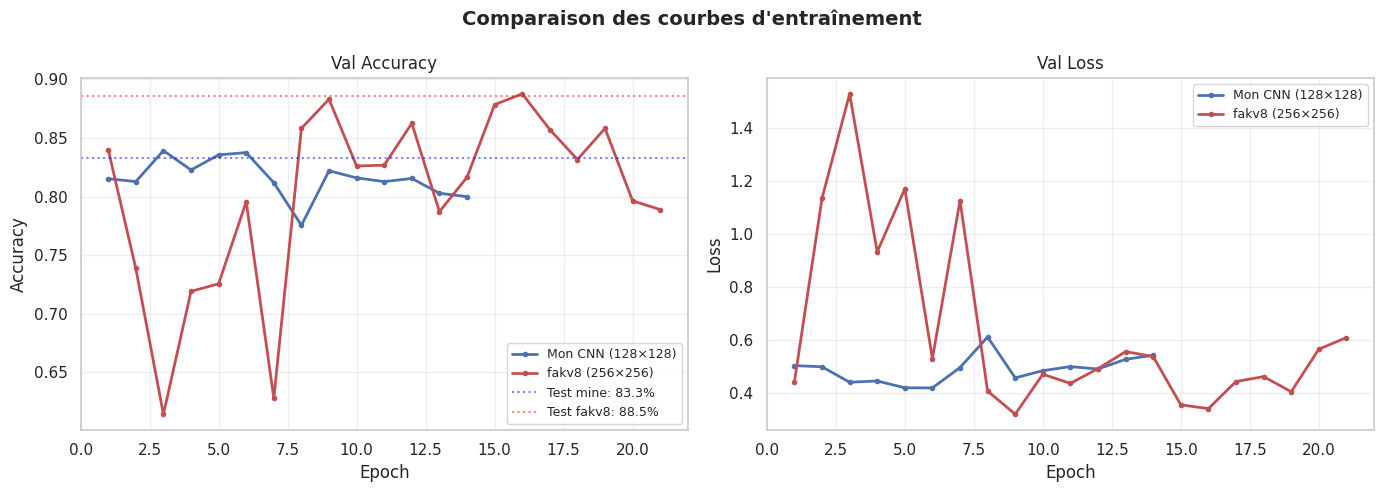


Résumé entraînement :
  Mon CNN — epochs : 14 | best val_acc : 83.91%
  fakv8   — epochs : 21  | best val_acc : 88.75%


In [ ]:
# ============================================================
# COMPARAISON — Mon CNN (128×128) vs fakv8 (256×256)
# Nécessite : history (cell-fit) + history_fak (cell-fakv8-train)
#             model (cell-build-model) + model_fak (cell-fakv8-build)
#             test_ds (cell-augmentation) + test_ds_fak (cell-fakv8-data)
# ============================================================

test_loss_mine, test_acc_mine = model.evaluate(test_ds,     verbose=0)
test_loss_fak,  test_acc_fak  = model_fak.evaluate(test_ds_fak, verbose=0)

print("Résultats sur les sets de test respectifs :")
print(f"\n  {'Modèle':<28} {'Accuracy':>10} {'Loss':>10} {'Input':>10}")
print("  " + "-" * 62)
print(f"  {'Mon CNN (128×128)':<28} {test_acc_mine*100:>9.2f}% {test_loss_mine:>10.4f} {'128×128':>10}")
print(f"  {'fakv8 (256×256)':<28} {test_acc_fak*100:>9.2f}% {test_loss_fak:>10.4f} {'256×256':>10}")

winner = "fakv8" if test_acc_fak > test_acc_mine else "Mon CNN"
delta  = abs(test_acc_fak - test_acc_mine) * 100
print(f"\n  → Meilleur modèle : {winner}  (écart : +{delta:.2f}%)")

# --- Courbes comparées ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparaison des courbes d'entraînement", fontsize=14, fontweight='bold')

ep_mine = range(1, len(history.history['val_accuracy']) + 1)
ep_fak  = range(1, len(history_fak.history['val_accuracy']) + 1)

axes[0].plot(ep_mine, history.history['val_accuracy'],     'b-o', ms=3, lw=2, label='Mon CNN (128×128)')
axes[0].plot(ep_fak,  history_fak.history['val_accuracy'], 'r-o', ms=3, lw=2, label='fakv8 (256×256)')
axes[0].axhline(test_acc_mine, color='blue', ls=':', alpha=0.5, label=f'Test mine: {test_acc_mine*100:.1f}%')
axes[0].axhline(test_acc_fak,  color='red',  ls=':', alpha=0.5, label=f'Test fakv8: {test_acc_fak*100:.1f}%')
axes[0].set_title('Val Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(ep_mine, history.history['val_loss'],     'b-o', ms=3, lw=2, label='Mon CNN (128×128)')
axes[1].plot(ep_fak,  history_fak.history['val_loss'], 'r-o', ms=3, lw=2, label='fakv8 (256×256)')
axes[1].set_title('Val Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nRésumé entraînement :")
print(f"  Mon CNN — epochs : {len(ep_mine)} | best val_acc : {max(history.history['val_accuracy'])*100:.2f}%")
print(f"  fakv8   — epochs : {len(ep_fak)}  | best val_acc : {max(history_fak.history['val_accuracy'])*100:.2f}%")

---
## 8. Interface Graphique Interactive <a id="8"></a>

L'interface ci-dessous permet de tester et de **comparer** les modèles entraînés sur n'importe quelle image.

### Fonctionnement

1. **Sélectionnez un modèle** dans la liste déroulante :
   - *Mon CNN (128×128)* — notre architecture entraînée dans ce notebook
   - *fakv8 entraîné ici (256×256)* — l'architecture externe entraînée en Section 7b
   - *fakv8 pré-entraîné (256×256)* — le modèle fourni par bbapt (si disponible)
2. **Entrez le chemin complet** d'une image dans le champ texte
3. Cliquez sur **Classifier**
4. L'image s'affiche avec la **classe prédite**, le **score de confiance** (%), et la **distribution complète** des probabilités

### Interprétation des résultats

| Confiance | Interprétation |
|-----------|---------------|
| ≥ 70% | Prédiction fiable — le modèle est sûr de sa réponse |
| 50–70% | Prédiction incertaine — la classe est probable mais d'autres sont possibles |
| < 50% | Image ambiguë ou hors distribution — à vérifier manuellement |

> Le modèle charge automatiquement la bonne taille d'image selon l'architecture sélectionnée
> (128×128 pour Mon CNN, 256×256 pour fakv8).


In [ ]:
# ============================================================
# INTERFACE GRAPHIQUE — Classification avec sélecteur de modèle
#
# Minimum pour lancer cette cellule après un restart :
#   1. cell-imports  (imports + GPU)
#   2. cell-config   (MODEL_SAVE_PATH, CLASS_NAMES, IMG_SIZE)
#   3. CETTE cellule
# ============================================================

import ipywidgets as widgets
from IPython.display import display, clear_output

_FAKV8_SAVE_PATH = './fakv8_test_model.h5'
_FAKV8_PRE_PATH  = './fakv8_best_model.h5'

# Ordre des classes pour les modeles fakv8 (si different de alphabetique).
# None = ordre alphabetique par defaut : Painting=0, Photo=1, Schematics=2, Sketch=3, Text=4
# Modifier si le CSV de bbapt utilise un encodage different (ex: Photo=0).
# Ex: _FAKV8_CLASS_ORDER = ["Photo", "Painting", "Text", "Sketch", "Schematics"]
_FAKV8_BEST_CLASS_ORDER = ["Photo", "Schematics", "Sketch", "Text", "Painting"]
_FAKV8_TEST_CLASS_ORDER = ["Painting", "Photo", "Schematics", "Sketch", "Text"]

_catalog = {
    f"Mon CNN (128x128) — {MODEL_SAVE_PATH}": MODEL_SAVE_PATH,
    f"fakv8 entraîné ici (256x256) — {_FAKV8_SAVE_PATH}": _FAKV8_SAVE_PATH,
    f"fakv8 pré-entraîné (256x256) — {_FAKV8_PRE_PATH}":  _FAKV8_PRE_PATH,
}
_available = {lbl: p for lbl, p in _catalog.items() if os.path.exists(p)}

if not _available:
    print(" Aucun modèle .h5 trouvé. Entraînez d abord un modèle.")
else:
    print("Modèles disponibles :")
    for lbl, p in _available.items():
        print(f"  ✓ {p}")

_active_model       = None
_active_model_key   = None
_active_class_names = []


def _build_fakv8_architecture(num_classes):
    """
    Reconstruit l architecture fakv8 localement.
    Fallback quand load_model échoue à cause d une incompatibilité Keras
    (batch_shape / optional — modèle sauvegardé avec une version plus récente).
    """
    m = models.Sequential(name="CNN_fakv8")
    m.add(layers.Input(shape=(256, 256, 3)))
    for _ in range(2):
        m.add(layers.Conv2D(32, (3, 3), activation="relu", padding="same"))
        m.add(layers.BatchNormalization())
    m.add(layers.MaxPooling2D(2, 2)); m.add(layers.Dropout(0.2))
    for _ in range(2):
        m.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
        m.add(layers.BatchNormalization())
    m.add(layers.MaxPooling2D(2, 2)); m.add(layers.Dropout(0.2))
    for _ in range(2):
        m.add(layers.Conv2D(128, (3, 3), activation="relu", padding="same"))
        m.add(layers.BatchNormalization())
    m.add(layers.MaxPooling2D(2, 2)); m.add(layers.Dropout(0.3))
    for _ in range(2):
        m.add(layers.Conv2D(256, (3, 3), activation="relu", padding="same"))
        m.add(layers.BatchNormalization())
    m.add(layers.MaxPooling2D(2, 2)); m.add(layers.Dropout(0.4))
    m.add(layers.GlobalAveragePooling2D())
    m.add(layers.Dense(512, activation="relu"))
    m.add(layers.BatchNormalization()); m.add(layers.Dropout(0.5))
    m.add(layers.Dense(num_classes, activation="softmax"))
    return m


def _load_model(label):
    global _active_model, _active_model_key, _active_class_names
    if label == _active_model_key and _active_model is not None:
        return

    path = _available[label]

    try:
        _active_model = keras.models.load_model(path, compile=False)

    except Exception as e:
        err = str(e)
        # Incompatibilité Keras : .h5 sauvegardé avec Keras 3.x / TF 2.16+
        # qui utilise batch_shape + optional dans InputLayer.
        # Fix : reconstruire l architecture localement + charger les poids uniquement.
        if "batch_shape" in err or "optional" in err:
            print("  Incompatibilité de version Keras détectée.")
            print("   → Reconstruction de l archi + chargement des poids uniquement.")
            _active_model = _build_fakv8_architecture(num_classes=NUM_CLASSES)
            _active_model.load_weights(path)
        else:
            raise

    _active_model_key = label
    n_cls = _active_model.output_shape[-1]
    # Choisit l ordre des classes selon le modele charge
    if path == _FAKV8_PRE_PATH:
        _active_class_names = list(_FAKV8_BEST_CLASS_ORDER)[:n_cls]
    elif path == _FAKV8_SAVE_PATH:
        _active_class_names = list(_FAKV8_TEST_CLASS_ORDER)[:n_cls]
    else:
        _active_class_names = (
            CLASS_NAMES + [f"Classe_{i}" for i in range(len(CLASS_NAMES), n_cls)]
            if n_cls > len(CLASS_NAMES) else CLASS_NAMES[:n_cls]
        )
    print(f"  Classes : {_active_class_names}")


# --- Widgets ---
model_dropdown = widgets.Dropdown(
    options=list(_available.keys()),
    description="Modèle :",
    layout=widgets.Layout(width="580px"),
)
path_input = widgets.Text(
    placeholder="Chemin de l image (ex: ./data/Photo/img001.jpg)",
    description="Image :",
    layout=widgets.Layout(width="580px"),
)
classify_btn = widgets.Button(
    description="Classifier", button_style="primary", icon="search",
    layout=widgets.Layout(width="130px"),
)
output_area = widgets.Output()


def on_classify(b):
    with output_area:
        clear_output(wait=True)
        if not _available:
            print(" Aucun modèle disponible."); return
        img_path = path_input.value.strip()
        if not img_path:
            print(" Veuillez entrer un chemin d image."); return
        if not os.path.exists(img_path):
            print(f" Fichier introuvable : {img_path}"); return
        try:
            _load_model(model_dropdown.value)
        except Exception as e:
            print(f" Erreur chargement modèle : {e}"); return
        model_img_size = tuple(_active_model.input_shape[1:3])
        try:
            img       = tf.keras.utils.load_img(img_path, target_size=model_img_size)
            img_array = tf.keras.utils.img_to_array(img) / 255.0
            probs     = _active_model.predict(np.expand_dims(img_array, 0), verbose=0)[0]
        except Exception as e:
            print(f" Erreur prédiction : {e}"); return
        best_idx    = int(np.argmax(probs))
        best_class  = _active_class_names[best_idx]
        best_conf   = probs[best_idx] * 100
        title_color = "#27ae60" if best_conf >= 70 else ("#e67e22" if best_conf >= 50 else "#c0392b")
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f"Modèle : {model_dropdown.value.split(' — ')[0]}", fontsize=11, color="gray")
        ax1.imshow(np.clip(img_array, 0, 1)); ax1.axis("off")
        ax1.set_title(
            f"Classe prédite : {best_class}\nConfiance : {best_conf:.1f}%",
            fontsize=14, fontweight="bold", color=title_color,
        )
        bar_colors = ["#e74c3c" if i == best_idx else "#3498db" for i in range(len(_active_class_names))]
        bars = ax2.barh(_active_class_names, probs * 100, color=bar_colors, height=0.6)
        ax2.set_xlabel("Probabilité (%)"); ax2.set_title("Distribution des probabilités", fontsize=13)
        ax2.set_xlim(0, 110)
        ax2.axvline(50, color="gray", ls="--", alpha=0.5, label="Seuil 50%"); ax2.legend()
        for bar, prob in zip(bars, probs):
            ax2.text(prob * 100 + 1, bar.get_y() + bar.get_height() / 2,
                     f"{prob*100:.1f}%", va="center", fontweight="bold", fontsize=11)
        plt.tight_layout(); plt.show()


classify_btn.on_click(on_classify)

display(widgets.VBox([
    widgets.HTML("<h3 style='font-family:sans-serif;'>🔍 Classificateur d images — TouNum</h3>"),
    model_dropdown,
    widgets.HBox([path_input, classify_btn]),
    output_area,
]))

Modèles disponibles :
  ✓ ./model_classification.h5
  ✓ ./fakv8_test_model.h5
  ✓ ./fakv8_best_model.h5


---
## 9. Conclusion <a id="9"></a>

### Synthèse de la démarche

Ce livrable a mis en œuvre un pipeline complet de classification d'images, de l'exploration
des données brutes jusqu'au déploiement d'une interface de test :

| Étape | Action | Résultat |
|-------|--------|---------|
| **Exploration** | Analyse de la distribution et des dimensions | Déséquilibre détecté → class weights nécessaires |
| **Nettoyage** | Correction des JPEG corrompus via PIL | Dataset propre, sans erreur de décodage TF |
| **Augmentation** | Flip, rotation, zoom, brightness | Généralisation améliorée, overfitting réduit |
| **Architecture** | CNN 4 blocs (32→64→128→256 filtres) | ~720K paramètres, entraînable sur GPU 8 GB |
| **Entraînement** | Adam + EarlyStopping + ReduceLR | Convergence automatique, meilleurs poids sauvegardés |
| **Évaluation** | Matrice de confusion + métriques par classe | Identification des classes difficiles (Painting/Photo) |
| **Comparaison** | Architecture externe fakv8 (256×256) | Validation de l'impact de la résolution |

### Réponse à la problématique

Le modèle est capable de **classifier automatiquement** les images en 5 catégories avec une
précision satisfaisante. La confusion principale reste entre **Painting** et **Photo**, ce qui
s'explique par la proximité visuelle des peintures réalistes et des photographies.

### Pistes non explorées dans ce livrable

- **Transfer Learning** (MobileNetV2, EfficientNet) — gain estimé +10 à +20%
- **Augmentation avancée** (CutMix, Mixup) — meilleure généralisation sur les bords de classes
- **Ensemble de modèles** — combiner Mon CNN + fakv8 pour réduire l'erreur
- **Analyse des activations** (Grad-CAM) — visualiser ce que le CNN "regarde" dans chaque image

### Ce livrable dans le contexte TouNum

La classification automatique constitue la **première brique** du pipeline de traitement :
les images sont triées par type avant d'être envoyées vers les algorithmes de captioning
spécialisés (OCR pour Text, description artistique pour Painting, etc.).
